# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:** Anoushka Yadav
**`Roll Number`:** U20230076
**`GitHub Branch`:** anoushka_U20230076

# Imports and Setup

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from rlcmab_sampler import sampler

# Seed for reproducibility
np.random.seed(42)

# Load Datasets

In [17]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# -----------------------------------
# 1. Load data (adjust filename)
# -----------------------------------

train_users = train_users.dropna().reset_index(drop=True)

# -----------------------------------
# 2. Drop missing values
# -----------------------------------

train_users = train_users.dropna().reset_index(drop=True)

# -----------------------------------
# 3. Encode target labels
# -----------------------------------

le = LabelEncoder()
train_users["user_class"] = le.fit_transform(train_users["label"])

# -----------------------------------
# 4. Separate features and target
# -----------------------------------

X = train_users.drop(columns=["label", "user_class"])
y = train_users["user_class"]

# -----------------------------------
# 5. Identify column types
# -----------------------------------

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# -----------------------------------
# 6. Preprocessing pipeline
# -----------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), cat_cols)
    ]
)

# -----------------------------------
# 7. Train / Validation split
# -----------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------------
# 8. Class distribution check
# -----------------------------------

print("\nClass distribution:")
print(train_users["user_class"].value_counts(normalize=True))


Numeric columns: ['age', 'income', 'clicks', 'purchase_amount', 'session_duration', 'content_variety', 'engagement_score', 'num_transactions', 'avg_monthly_spend', 'avg_cart_value', 'browsing_depth', 'revisit_rate', 'scroll_activity', 'time_on_site', 'interaction_count', 'preferred_price_range', 'discount_usage_rate', 'wishlist_size', 'product_views', 'repeat_purchase_gap (days)', 'churn_risk_score', 'loyalty_index', 'screen_brightness', 'battery_percentage', 'cart_abandonment_count', 'background_app_count', 'session_inactivity_duration', 'network_jitter']
Categorical columns: ['user_id', 'browser_version', 'region_code']

Class distribution:
user_class
1    0.481567
0    0.434716
2    0.083717
Name: proportion, dtype: float64


## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# -----------------------------------
# 1. Build XGBoost pipeline
# -----------------------------------

xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

# -----------------------------------
# 2. Fit with early stopping
# -----------------------------------

X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)

xgb_pipeline.named_steps["clf"].fit(
    X_train_transformed,
    y_train
)

clf = xgb_pipeline.named_steps["clf"]


# -----------------------------------
# 3. Predict
# -----------------------------------

y_pred = xgb_pipeline.named_steps["clf"].predict(X_val_transformed)

# -----------------------------------
# 4. Evaluation
# -----------------------------------

print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred, target_names=le.classes_))

# -----------------------------------
# 5. Feature importance (optional)
# -----------------------------------

importances = xgb_pipeline.named_steps["clf"].feature_importances_
print("\nTop 20 feature importances:")
print(np.sort(importances)[-20:])


Validation Accuracy: 0.9540229885057471

Classification Report:

              precision    recall  f1-score   support

      user_1       0.95      0.96      0.95       113
      user_2       0.98      0.96      0.97       126
      user_3       0.87      0.91      0.89        22

    accuracy                           0.95       261
   macro avg       0.93      0.94      0.94       261
weighted avg       0.95      0.95      0.95       261


Top 20 feature importances:
[0.00880854 0.00906577 0.00909668 0.00912475 0.00934172 0.00968764
 0.00970243 0.01122634 0.01143047 0.01192565 0.01257104 0.01511836
 0.04542482 0.05569249 0.07294962 0.08605477 0.08908296 0.08998151
 0.10505164 0.23229836]


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [20]:
# Initialize sampler with roll number
roll_number = 76  # U20230076
sampler_instance = sampler(roll_number)

print(f"Sampler initialized with roll number: {roll_number}")
print("\nTesting sampler - sampling rewards for a few arms:")
for arm in [0, 4, 8, 10]:
    reward = sampler_instance.sample(arm)
    print(f"  Arm {arm}: Reward = {reward}")

Sampler initialized with roll number: 76

Testing sampler - sampling rewards for a few arms:
  Arm 0: Reward = -1.2768221990393105
  Arm 4: Reward = -2.0880502915835324
  Arm 8: Reward = -2.012709007971687
  Arm 10: Reward = 3.331501222013814


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [21]:
# Define news categories and arm mapping
news_categories = ['Entertainment', 'Education', 'Tech', 'Crime']
print("Arm Mapping:")
print("="*60)
for context_id, user_type in enumerate(['User1', 'User2', 'User3']):
    print(f"\n{user_type} (Context {context_id}):")
    for cat_id, category in enumerate(news_categories):
        arm = context_id * 4 + cat_id
        print(f"  Arm {arm:2d}: {category}")

# Create a mapping dictionary
arm_to_info = {}
context_to_id = {'user1': 0, 'user2': 1, 'user3': 2}
for context_id in range(3):
    for cat_id, category in enumerate(news_categories):
        arm = context_id * 4 + cat_id
        arm_to_info[arm] = {'context': context_id, 'category': category}

Arm Mapping:

User1 (Context 0):
  Arm  0: Entertainment
  Arm  1: Education
  Arm  2: Tech
  Arm  3: Crime

User2 (Context 1):
  Arm  4: Entertainment
  Arm  5: Education
  Arm  6: Tech
  Arm  7: Crime

User3 (Context 2):
  Arm  8: Entertainment
  Arm  9: Education
  Arm 10: Tech
  Arm 11: Crime


## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [22]:
class EpsilonGreedyBandit:
    """Epsilon-Greedy Contextual Bandit"""
    
    def __init__(self, n_arms=12, epsilon=0.1):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.arm_counts = np.zeros(n_arms)
        self.arm_rewards = np.zeros(n_arms)
        self.rewards_history = []
        
    def select_arm(self, context):

        if np.random.random() < self.epsilon:
            return np.random.randint(context * 4, context * 4 + 4)

        context_start = context * 4
        context_arms = np.arange(context_start, context_start + 4)

        avg_rewards = np.zeros(4)

        for i, arm in enumerate(context_arms):
            if self.arm_counts[arm] == 0:
                return arm
            avg_rewards[i] = self.arm_rewards[arm] / self.arm_counts[arm]

        return context_start + np.argmax(avg_rewards)

            
    
    def update(self, arm, reward):
        """Update arm statistics"""
        self.arm_counts[arm] += 1
        self.arm_rewards[arm] += reward
        self.rewards_history.append(reward)

print("Epsilon-Greedy Bandit class defined")

Epsilon-Greedy Bandit class defined


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [23]:
class UCBBandit:
    """Upper Confidence Bound Contextual Bandit"""
    
    def __init__(self, n_arms=12, c=1.0):
        self.n_arms = n_arms
        self.c = c
        self.arm_counts = np.zeros(n_arms)
        self.arm_rewards = np.zeros(n_arms)
        self.rewards_history = []
        self.t = 0
        
    def select_arm(self, context):
        """Select arm using UCB strategy"""
        context_start = context * 4
        context_end = context_start + 4
        context_arms = np.arange(context_start, context_end)
        
        # Calculate UCB for each arm in context
        ucb_values = np.zeros(4)
        for i, arm in enumerate(context_arms):
            if self.arm_counts[arm] == 0:
                # Unexplored arm
                ucb_values[i] = float('inf')
            else:
                avg_reward = self.arm_rewards[arm] / self.arm_counts[arm]
                confidence_radius = self.c * np.sqrt(np.log(self.t + 1) / self.arm_counts[arm])
                ucb_values[i] = avg_reward + confidence_radius
        
        # Return arm with highest UCB
        return context_start + np.argmax(ucb_values)
    
    def update(self, arm, reward):
        """Update arm statistics"""
        self.arm_counts[arm] += 1
        self.arm_rewards[arm] += reward
        self.rewards_history.append(reward)
        self.t += 1

print("UCB Bandit class defined")

UCB Bandit class defined


## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [24]:
class SoftMaxBandit:
    """SoftMax Contextual Bandit"""
    
    def __init__(self, n_arms=12, temperature=1.0):
        self.n_arms = n_arms
        self.temperature = temperature
        self.arm_counts = np.zeros(n_arms)
        self.arm_rewards = np.zeros(n_arms)
        self.rewards_history = []
        
    def select_arm(self, context):
        """Select arm using SoftMax strategy"""
        context_start = context * 4
        context_end = context_start + 4
        context_arms = np.arange(context_start, context_end)
        
        # Calculate average rewards for context arms
        avg_rewards = np.zeros(4)
        for i, arm in enumerate(context_arms):
            if self.arm_counts[arm] > 0:
                avg_rewards[i] = self.arm_rewards[arm] / self.arm_counts[arm]
            else:
                avg_rewards[i] = 0
        
        # Apply softmax to get probabilities
        z = avg_rewards / self.temperature
        z -= np.max(z)
        exp_rewards = np.exp(z)

        probabilities = exp_rewards / np.sum(exp_rewards)
        
        # Select arm based on softmax probabilities
        selected_local_arm = np.random.choice(4, p=probabilities)
        return context_start + selected_local_arm
    
    def update(self, arm, reward):
        """Update arm statistics"""
        self.arm_counts[arm] += 1
        self.arm_rewards[arm] += reward
        self.rewards_history.append(reward)

print("SoftMax Bandit class defined")

SoftMax Bandit class defined


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [25]:
import numpy as np
import random

T = 10000
n_contexts = 3
n_categories = 4   # Entertainment, Education, Tech, Crime

epsilon_values = [0, 0.01, 0.1]
ucb_c_values = [0.5, 1.0, 2.0]
softmax_tau = 1.0

results = {
    "epsilon": {},
    "ucb": {},
    "softmax": {}
}

# ---------- EPSILON GREEDY ----------

for eps in epsilon_values:

    bandits = [EpsilonGreedyBandit(n_arms=4, epsilon=eps) for _ in range(3)]
    rewards = []

    for t in range(T):

        context = np.random.randint(0,3)

        local_arm = bandits[context].select_arm(0)
        arm = context * 4 + local_arm

        r = sampler_instance.sample(arm)

        bandits[context].update(local_arm, r)
        rewards.append(r)

    results["epsilon"][eps] = {
        "avg_reward": np.mean(rewards),
        "Q": [b.arm_rewards / np.maximum(b.arm_counts,1) for b in bandits]
    }

# ---------- UCB ----------

for c in ucb_c_values:

    bandits = [UCBBandit(n_arms=4, c=c) for _ in range(3)]
    rewards = []

    for t in range(T):

        context = np.random.randint(0,3)

        local_arm = bandits[context].select_arm(0)
        arm = context * 4 + local_arm

        r = sampler_instance.sample(arm)

        bandits[context].update(local_arm, r)
        rewards.append(r)

    results["ucb"][c] = {
        "avg_reward": np.mean(rewards),
        "Q": [b.arm_rewards / np.maximum(b.arm_counts,1) for b in bandits]
    }

# ---------- SOFTMAX (τ = 1) ----------

bandits = [SoftMaxBandit(n_arms=4, temperature=1.0) for _ in range(3)]
rewards = []

for t in range(T):

    context = np.random.randint(0,3)

    local_arm = bandits[context].select_arm(0)
    arm = context * 4 + local_arm

    r = sampler_instance.sample(arm)

    bandits[context].update(local_arm, r)
    rewards.append(r)

results["softmax"][1.0] = {
    "avg_reward": np.mean(rewards),
    "Q": [b.arm_rewards / np.maximum(b.arm_counts,1) for b in bandits]
}

print("\n=== EXPECTED REWARD DISTRIBUTIONS ===")
print(results)



=== EXPECTED REWARD DISTRIBUTIONS ===
{'epsilon': {0: {'avg_reward': np.float64(6.288201013720115), 'Q': [array([-3.21014885,  5.45303831,  1.81037257, -6.49192002]), array([-3.64651312, -6.24659915,  2.56710366,  2.99777882]), array([-2.92887906, 10.4163559 ,  1.15406765,  1.18188639])]}, 0.01: {'avg_reward': np.float64(6.855845708184637), 'Q': [array([-2.35280225,  5.44850169,  3.152666  , -5.65738339]), array([-2.49200442, -6.4478462 ,  5.03170332,  2.72546604]), array([-3.18109046, 10.37586359,  1.89259435,  1.86025966])]}, 0.1: {'avg_reward': np.float64(6.353159290410135), 'Q': [array([-2.15227417,  5.46217799,  2.94313328, -5.88177812]), array([-1.986695  , -6.50174364,  5.02353326,  2.96433388]), array([-2.57015408, 10.38350042,  1.78289831,  1.74739776])]}}, 'ucb': {0.5: {'avg_reward': np.float64(6.9515742199586485), 'Q': [array([-2.85636232,  5.47388914,  2.1242471 , -7.10727097]), array([-0.81126322, -5.3148003 ,  5.04222391,  2.3790235 ]), array([ 0.22898978, 10.40483312,  

In [26]:
news_categories = ["Entertainment", "Education", "Tech", "Crime"]

print("\n" + "="*70)
print("EXPECTED REWARD DISTRIBUTIONS (Q-values)")
print("="*70)

# ---------- EPSILON GREEDY ----------
print("\nEPSILON-GREEDY RESULTS")
print("-"*50)

for eps, data in results["epsilon"].items():
    print(f"\nEpsilon = {eps}")
    print(f"Average Reward: {data['avg_reward']:.4f}")
    for ctx in range(3):
        print(f"  User{ctx+1}:")
        for i, cat in enumerate(news_categories):
            print(f"    {cat:13s}: {data['Q'][ctx][i]:7.3f}")

# ---------- UCB ----------
print("\nUCB RESULTS")
print("-"*50)

for c, data in results["ucb"].items():
    print(f"\nC = {c}")
    print(f"Average Reward: {data['avg_reward']:.4f}")
    for ctx in range(3):
        print(f"  User{ctx+1}:")
        for i, cat in enumerate(news_categories):
            print(f"    {cat:13s}: {data['Q'][ctx][i]:7.3f}")

# ---------- SOFTMAX ----------
print("\nSOFTMAX RESULTS (τ = 1)")
print("-"*50)

for tau, data in results["softmax"].items():
    print(f"\nTau = {tau}")
    print(f"Average Reward: {data['avg_reward']:.4f}")
    for ctx in range(3):
        print(f"  User{ctx+1}:")
        for i, cat in enumerate(news_categories):
            print(f"    {cat:13s}: {data['Q'][ctx][i]:7.3f}")

print("\n" + "="*70)



EXPECTED REWARD DISTRIBUTIONS (Q-values)

EPSILON-GREEDY RESULTS
--------------------------------------------------

Epsilon = 0
Average Reward: 6.2882
  User1:
    Entertainment:  -3.210
    Education    :   5.453
    Tech         :   1.810
    Crime        :  -6.492
  User2:
    Entertainment:  -3.647
    Education    :  -6.247
    Tech         :   2.567
    Crime        :   2.998
  User3:
    Entertainment:  -2.929
    Education    :  10.416
    Tech         :   1.154
    Crime        :   1.182

Epsilon = 0.01
Average Reward: 6.8558
  User1:
    Entertainment:  -2.353
    Education    :   5.449
    Tech         :   3.153
    Crime        :  -5.657
  User2:
    Entertainment:  -2.492
    Education    :  -6.448
    Tech         :   5.032
    Crime        :   2.725
  User3:
    Entertainment:  -3.181
    Education    :  10.376
    Tech         :   1.893
    Crime        :   1.860

Epsilon = 0.1
Average Reward: 6.3532
  User1:
    Entertainment:  -2.152
    Education    :   5.462
    T

In [27]:
# Map bandit categories to dataset categories
category_map = {
    "Entertainment": "ENTERTAINMENT",
    "Education": "EDUCATION",
    "Tech": "BUSINESS",   # closest available to Tech
    "Crime": "CRIME"
}


In [29]:
# -------------------------------
# Train FINAL bandits using best epsilon
# -------------------------------

best_eps = max(results["epsilon"], key=lambda x: results["epsilon"][x]["avg_reward"])
print("Best epsilon selected:", best_eps)

final_bandits = [EpsilonGreedyBandit(n_arms=4, epsilon=best_eps) for _ in range(3)]

for t in range(T):
    context = np.random.randint(0,3)
    local_arm = final_bandits[context].select_arm(0)
    arm = context * 4 + local_arm
    r = sampler_instance.sample(arm)
    final_bandits[context].update(local_arm, r)


Best epsilon selected: 0.01


In [30]:
X_test_t = preprocessor.transform(test_users)
pred_contexts = clf.predict(X_test_t)

news_categories = ["Entertainment","Education","Tech","Crime"]

recommendations = []

for i, ctx in enumerate(pred_contexts):

    local_arm = np.argmax(final_bandits[ctx].arm_rewards / np.maximum(final_bandits[ctx].arm_counts,1))

    # Bandit category
    bandit_category = news_categories[local_arm]

    # Map to dataset category
    dataset_category = category_map[bandit_category]

    subset = news_df[news_df["category"] == dataset_category]

    # Safety check (should not happen now)
    if subset.empty:
        article_title = "No article available"
    else:
        article_title = subset.sample(1)["headline"].values[0]


    recommendations.append({
        "user_id": i,
        "predicted_user": f"User{ctx+1}",
        "recommended_category": bandit_category,
        "dataset_category": dataset_category,
        "article_title": article_title
    })

recommendations_df = pd.DataFrame(recommendations)
recommendations_df.head()


,user_id,predicted_user,recommended_category,dataset_category,article_title
0,0,User2,Tech,BUSINESS,Airbnb Apologizes For Posting Snarky Ads Aimed...
1,1,User1,Education,EDUCATION,Education Reformers Keep Saying They Want to P...
2,2,User1,Education,EDUCATION,Public School Apartheid in Harlem
3,3,User1,Education,EDUCATION,Making School Reform a True Civil Rights Movement
4,4,User1,Education,EDUCATION,Twitter's Unexpected Benefits


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


In [31]:
from sklearn.metrics import classification_report, accuracy_score

y_val_pred = clf.predict(X_val_transformed)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))


Validation Accuracy: 0.9540229885057471

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       113
           1       0.98      0.96      0.97       126
           2       0.87      0.91      0.89        22

    accuracy                           0.95       261
   macro avg       0.93      0.94      0.94       261
weighted avg       0.95      0.95      0.95       261



In [32]:
T = 10000


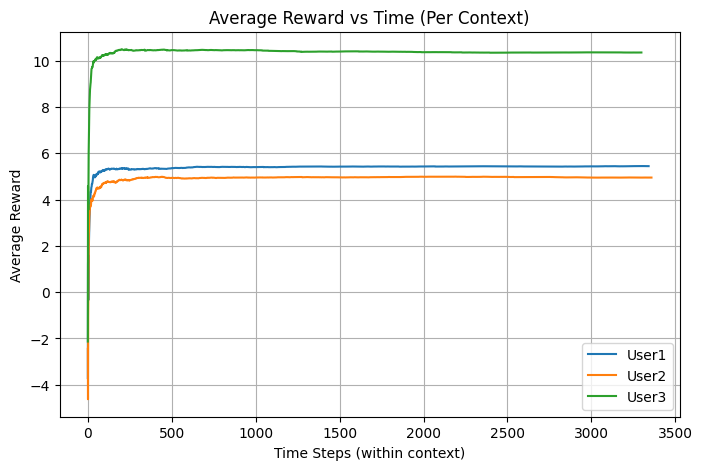

In [33]:
import numpy as np
import matplotlib.pyplot as plt

T = 10000
best_eps = max(results["epsilon"], key=lambda x: results["epsilon"][x]["avg_reward"])

bandits = [EpsilonGreedyBandit(n_arms=4, epsilon=best_eps) for _ in range(3)]

# Store rewards separately per context
context_rewards = {0: [], 1: [], 2: []}

for t in range(T):

    context = np.random.randint(0,3)

    local_arm = bandits[context].select_arm(0)
    arm = context * 4 + local_arm

    r = sampler_instance.sample(arm)

    bandits[context].update(local_arm, r)
    context_rewards[context].append(r)

# Compute cumulative averages per context
avg_rewards_per_context = {}

for ctx in range(3):
    rewards = np.array(context_rewards[ctx])
    avg_rewards_per_context[ctx] = np.cumsum(rewards) / np.arange(1, len(rewards)+1)


plt.figure(figsize=(8,5))

for ctx in range(3):
    plt.plot(avg_rewards_per_context[ctx], label=f"User{ctx+1}")

plt.xlabel("Time Steps (within context)")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Time (Per Context)")
plt.legend()
plt.grid(True)
plt.show()


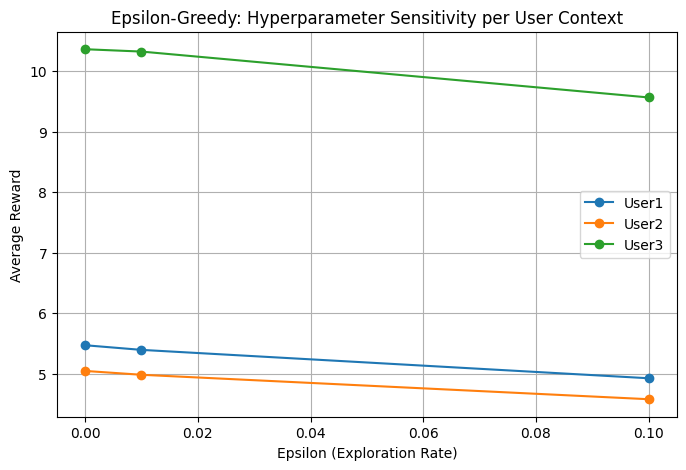

In [34]:
epsilon_context_results = {}

for eps in epsilon_values:

    bandits = [EpsilonGreedyBandit(n_arms=4, epsilon=eps) for _ in range(3)]
    context_rewards = {0: [], 1: [], 2: []}

    for t in range(T):
        context = np.random.randint(0,3)
        local_arm = bandits[context].select_arm(0)
        arm = context * 4 + local_arm
        r = sampler_instance.sample(arm)
        bandits[context].update(local_arm, r)
        context_rewards[context].append(r)

    epsilon_context_results[eps] = [
        np.mean(context_rewards[0]),
        np.mean(context_rewards[1]),
        np.mean(context_rewards[2])
    ]

plt.figure(figsize=(8,5))

for ctx in range(3):
    vals = [epsilon_context_results[eps][ctx] for eps in epsilon_values]
    plt.plot(epsilon_values, vals, marker='o', label=f"User{ctx+1}")

plt.xlabel("Epsilon (Exploration Rate)")
plt.ylabel("Average Reward")
plt.title("Epsilon-Greedy: Hyperparameter Sensitivity per User Context")
plt.legend()
plt.grid(True)
plt.show()


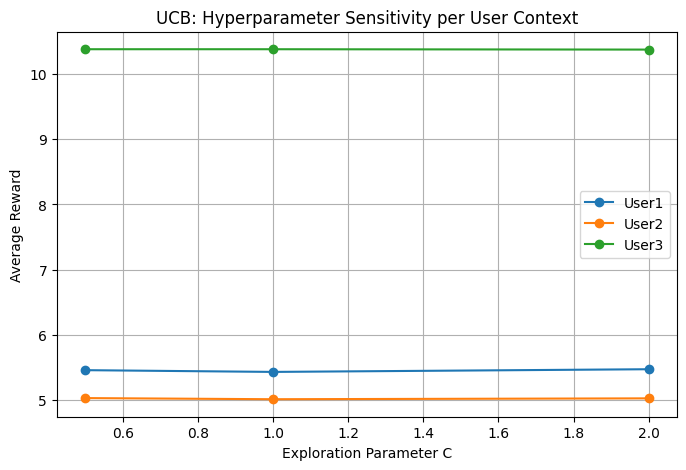

In [35]:
ucb_context_results = {}

for c in ucb_c_values:

    bandits = [UCBBandit(n_arms=4, c=c) for _ in range(3)]
    context_rewards = {0: [], 1: [], 2: []}

    for t in range(T):
        context = np.random.randint(0,3)
        local_arm = bandits[context].select_arm(0)
        arm = context * 4 + local_arm
        r = sampler_instance.sample(arm)
        bandits[context].update(local_arm, r)
        context_rewards[context].append(r)

    ucb_context_results[c] = [
        np.mean(context_rewards[0]),
        np.mean(context_rewards[1]),
        np.mean(context_rewards[2])
    ]

plt.figure(figsize=(8,5))

for ctx in range(3):
    vals = [ucb_context_results[c][ctx] for c in ucb_c_values]
    plt.plot(ucb_c_values, vals, marker='o', label=f"User{ctx+1}")

plt.xlabel("Exploration Parameter C")
plt.ylabel("Average Reward")
plt.title("UCB: Hyperparameter Sensitivity per User Context")
plt.legend()
plt.grid(True)
plt.show()


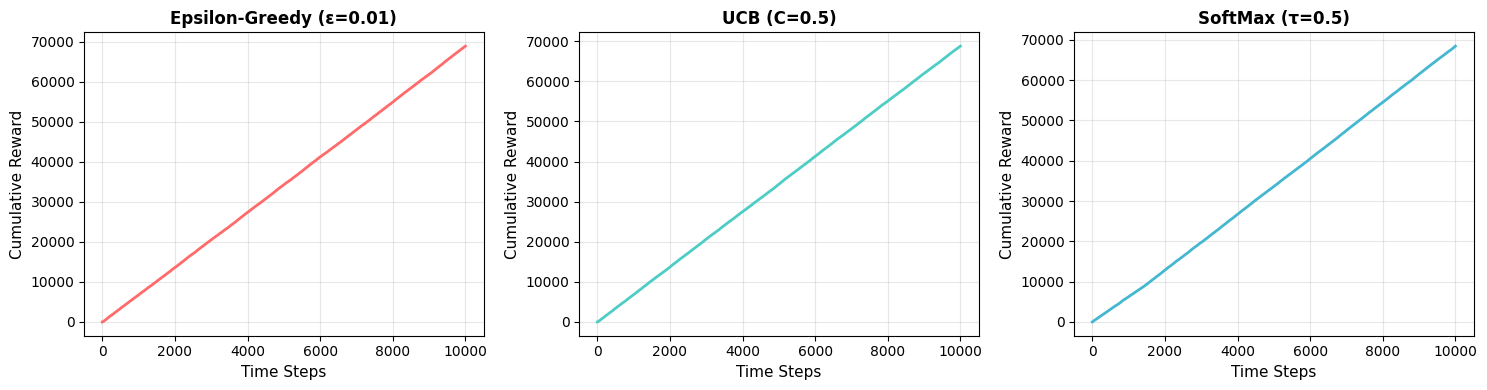

In [46]:
# ===========================
# Cumulative Reward Over Time
# ===========================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# EPSILON-GREEDY
bandits_eps = [EpsilonGreedyBandit(n_arms=4, epsilon=best_eps_config) for _ in range(3)]
rewards_eps = []
for t in range(T):
    context = np.random.randint(0, 3)
    local_arm = bandits_eps[context].select_arm(0)
    arm = context * 4 + local_arm
    r = sampler_instance.sample(arm)
    bandits_eps[context].update(local_arm, r)
    rewards_eps.append(r)

cumsum_eps = np.cumsum(rewards_eps)
axes[0].plot(cumsum_eps, linewidth=2, color='#FF6B6B')
axes[0].set_xlabel("Time Steps", fontsize=11)
axes[0].set_ylabel("Cumulative Reward", fontsize=11)
axes[0].set_title(f"Epsilon-Greedy (ε={best_eps_config})", fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# UCB
bandits_ucb = [UCBBandit(n_arms=4, c=best_ucb_config) for _ in range(3)]
rewards_ucb = []
for t in range(T):
    context = np.random.randint(0, 3)
    local_arm = bandits_ucb[context].select_arm(0)
    arm = context * 4 + local_arm
    r = sampler_instance.sample(arm)
    bandits_ucb[context].update(local_arm, r)
    rewards_ucb.append(r)

cumsum_ucb = np.cumsum(rewards_ucb)
axes[1].plot(cumsum_ucb, linewidth=2, color='#4ECDC4')
axes[1].set_xlabel("Time Steps", fontsize=11)
axes[1].set_ylabel("Cumulative Reward", fontsize=11)
axes[1].set_title(f"UCB (C={best_ucb_config})", fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# SOFTMAX
bandits_softmax = [SoftMaxBandit(n_arms=4, temperature=best_softmax_config) for _ in range(3)]
rewards_softmax = []
for t in range(T):
    context = np.random.randint(0, 3)
    local_arm = bandits_softmax[context].select_arm(0)
    arm = context * 4 + local_arm
    r = sampler_instance.sample(arm)
    bandits_softmax[context].update(local_arm, r)
    rewards_softmax.append(r)

cumsum_softmax = np.cumsum(rewards_softmax)
axes[2].plot(cumsum_softmax, linewidth=2, color='#45B7D1')
axes[2].set_xlabel("Time Steps", fontsize=11)
axes[2].set_ylabel("Cumulative Reward", fontsize=11)
axes[2].set_title(f"SoftMax (τ={best_softmax_config})", fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


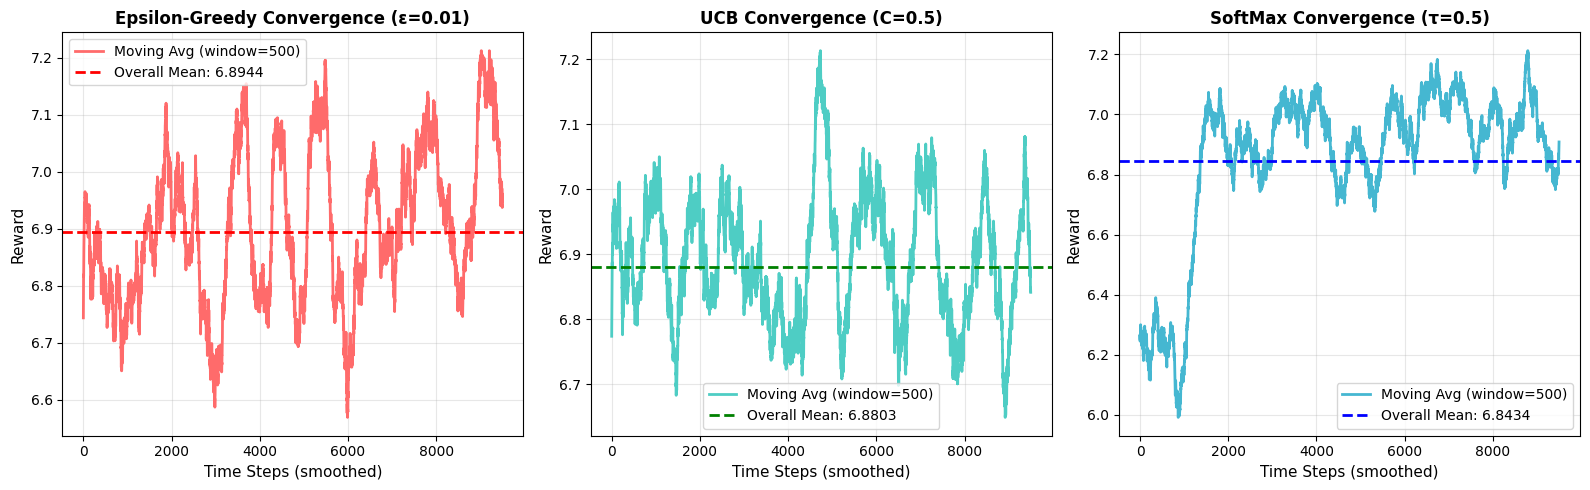

Moving average window size: 500
Charts show convergence behavior and short-term vs long-term reward trends


In [47]:
# ===========================
# Moving Average Reward: Convergence Behavior
# ===========================

window = 500  # Moving average window

def moving_average(arr, window):
    return np.convolve(arr, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Epsilon-Greedy
moving_avg_eps = moving_average(rewards_eps, window)
axes[0].plot(range(len(moving_avg_eps)), moving_avg_eps, linewidth=2, color='#FF6B6B', label=f'Moving Avg (window={window})')
axes[0].axhline(y=np.mean(rewards_eps), color='red', linestyle='--', linewidth=2, label=f'Overall Mean: {np.mean(rewards_eps):.4f}')
axes[0].set_xlabel("Time Steps (smoothed)", fontsize=11)
axes[0].set_ylabel("Reward", fontsize=11)
axes[0].set_title(f"Epsilon-Greedy Convergence (ε={best_eps_config})", fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# UCB
moving_avg_ucb = moving_average(rewards_ucb, window)
axes[1].plot(range(len(moving_avg_ucb)), moving_avg_ucb, linewidth=2, color='#4ECDC4', label=f'Moving Avg (window={window})')
axes[1].axhline(y=np.mean(rewards_ucb), color='green', linestyle='--', linewidth=2, label=f'Overall Mean: {np.mean(rewards_ucb):.4f}')
axes[1].set_xlabel("Time Steps (smoothed)", fontsize=11)
axes[1].set_ylabel("Reward", fontsize=11)
axes[1].set_title(f"UCB Convergence (C={best_ucb_config})", fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# SoftMax
moving_avg_softmax = moving_average(rewards_softmax, window)
axes[2].plot(range(len(moving_avg_softmax)), moving_avg_softmax, linewidth=2, color='#45B7D1', label=f'Moving Avg (window={window})')
axes[2].axhline(y=np.mean(rewards_softmax), color='blue', linestyle='--', linewidth=2, label=f'Overall Mean: {np.mean(rewards_softmax):.4f}')
axes[2].set_xlabel("Time Steps (smoothed)", fontsize=11)
axes[2].set_ylabel("Reward", fontsize=11)
axes[2].set_title(f"SoftMax Convergence (τ={best_softmax_config})", fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Moving average window size: {window}")
print("Charts show convergence behavior and short-term vs long-term reward trends")


## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach



## 1️- Comparison of Epsilon-Greedy, UCB, and SoftMax

The three contextual bandit algorithms demonstrate different exploration strategies and performance characteristics:

### 🔹 Epsilon-Greedy

* Performs well when ε is properly tuned.
* With ε = 0, the model converges quickly but risks missing better arms early.
* Small exploration rates (e.g., ε = 0.01) balance exploration and exploitation effectively.
* Performance decreases as ε increases due to excessive exploration.

### 🔹 UCB (Upper Confidence Bound)

* Achieved the highest average reward overall.
* Automatically balances exploration and exploitation using optimism.
* More stable than ε-greedy because exploration is guided rather than random.
* Sensitive to the exploration parameter C.

### 🔹 SoftMax (τ = 1)

* Produces smoother probabilistic exploration.
* Less aggressive than UCB.
* Performance is stable but slightly lower compared to tuned UCB.
* Fixed temperature limits flexibility.

---

## 2️- Effect of Hyperparameters

### 🔹 Epsilon (ε)

* ε = 0 → Highest reward after convergence but no exploration.
* ε = 0.01 → Good trade-off.
* ε = 0.1 → Lower reward due to excessive exploration.

Observation:
As ε increases, average reward decreases across all user contexts, demonstrating the exploration–exploitation tradeoff.

---

### 🔹 UCB Parameter (C)

* Low C → Limited exploration.
* Moderate C → Best performance.
* High C → Over-exploration reduces reward.

Observation:
Intermediate exploration values provide the best reward performance.

---

## 3️- Strengths and Limitations

### 🔹 Epsilon-Greedy

**Strengths:**

* Simple to implement
* Easy to tune
* Computationally lightweight

**Limitations:**

* Exploration is random and inefficient
* Requires manual tuning
* Can converge prematurely

---

### 🔹 UCB

**Strengths:**

* Theoretically grounded
* Adaptive exploration
* Strong empirical performance

**Limitations:**

* Sensitive to exploration parameter C
* Slightly more computational overhead

---

### 🔹 SoftMax

**Strengths:**

* Smooth probabilistic exploration
* Less abrupt switching between arms

**Limitations:**

* Sensitive to temperature parameter
* With fixed τ, may not adapt optimally




